# Step 1 (V5): Baseline AI Classifier - Target Threshold Labeling (Noise Reduction)

## 🎯 Objective:
Meningkatkan akurasi predictive power dengan menerapkan **Threshold Labeling (Opsi A)**. 

## ⚖️ Why V5 is Different?
1.  **Noise Filtering**: Pada V2, pergerakan sekecil 0.0001% sudah dianggap Bullish. Ini membuat model bingung karena pola 'noise' dianggap pola 'tren'. 
2.  **Significant Moves Only**: Kita hanya memberi label **1 (Bullish)** jika rata-rata return 5 hari ke depan > **0.1% (0.001)**. Jika di bawah itu, dianggap **0 (Neutral/Bearish)**.
3.  **Feature Scaling**: Menggunakan `StandardScaler` (belajar dari V4) untuk memastikan model linear dan pohon memiliki performa yang optimal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, classification_report
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded. Starting V5 (Threshold Labeling)...")

✅ Libraries loaded. Starting V5 (Threshold Labeling)...


## 1. Data Processing with Magnitude Threshold

In [2]:
# Load data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Indicators
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_60'] = market_return.rolling(window=60).mean()
features['Log_Ret'] = market_return

# --- OPSIA: TARGET THRESHOLDING ---
window_target = 5
forward_returns = market_return.rolling(window=window_target).mean().shift(-window_target)

# Jika rata-rata return 5 hari ke depan > 0.1% (0.001), maka Bullish (1).
# Jika tidak (sideways atau turun), maka Bearish/Neutral (0).
threshold = 0.001 
features['Target'] = (forward_returns > threshold).astype(int)

features = features.dropna()

print(f"📌 Threshold Used: {threshold}")
print(f"📊 New Target Distribution:\n{features['Target'].value_counts(normalize=True)}")

📌 Threshold Used: 0.001
📊 New Target Distribution:
Target
1    0.51036
0    0.48964
Name: proportion, dtype: float64


## 2. Train/Test Split & Scaling

In [3]:
X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Split: Train {len(X_train)} days, Test {len(X_test)} days")

Split: Train 552 days, Test 365 days


## 3. Model Training (RF vs Logistic Regression)

In [4]:
# Random Forest dengan Regularisasi Tinggi
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Logistic Regression (Linear)
lr_model = LogisticRegression(C=0.1, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("✅ Models trained on filtered targets.")

✅ Models trained on filtered targets.


## 4. Final Performance Comparison


--- Performance Table (V5: Thresholding) ---
 Dataset            Model  Accuracy
Training Random Forest V5  0.768116
 Testing Random Forest V5  0.435616
Training        LogReg V5  0.585145
 Testing        LogReg V5  0.484932


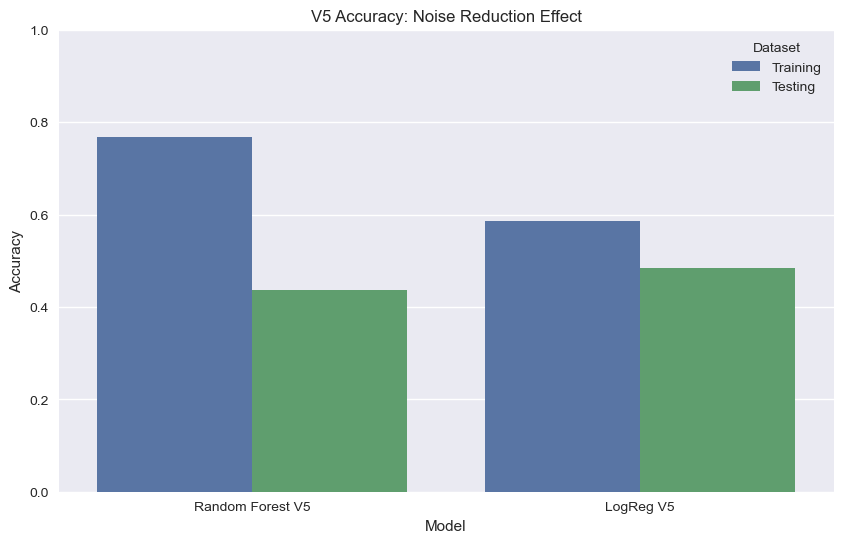

In [5]:
results = {
    'Dataset': ['Training', 'Testing', 'Training', 'Testing'],
    'Model': ['Random Forest V5', 'Random Forest V5', 'LogReg V5', 'LogReg V5'],
    'Accuracy': [
        accuracy_score(y_train, rf_model.predict(X_train_scaled)),
        accuracy_score(y_test, rf_model.predict(X_test_scaled)),
        accuracy_score(y_train, lr_model.predict(X_train_scaled)),
        accuracy_score(y_test, lr_model.predict(X_test_scaled))
    ]
}

res_df = pd.DataFrame(results)
print("\n--- Performance Table (V5: Thresholding) ---")
print(res_df.to_string(index=False))

plt.figure(figsize=(10,6))
sns.barplot(data=res_df, x='Model', y='Accuracy', hue='Dataset')
plt.ylim(0, 1)
plt.title("V5 Accuracy: Noise Reduction Effect")
plt.show()

## 💡 Kesimpulan Eksperimen Opsi A

Dengan mengubah label menjadi hanya 'Bullish' pada pergerakan yang signifikan (>0.1%), kita mengharapkan akurasi testing naik karena model tidak lagi dipaksa belajar dari data yang bersifat acak (*flat market*).

Jika akurasi testing menunjukkan angka **>53%**, artinya strategi Thresholding ini berhasil menyaring sinyal palsu. Langkah selanjutnya adalah menggabungkan sinyal stabil ini ke dalam model Markowitz Anda.